<table align="left" style="border-style: hidden" class="table"> <tr><td class="col-md-2"><img style="float: left; width: 200px; height: 200px;" src="../logo.png" alt="Data 140 Logo" style="width: 120px;"/></td><td><div align="left"><h3 style="margin-top: 0;">Probability for Data Science</h3><h4 style="margin-top: 20px;">UC Berkeley, Spring 2026</h4><p>Ani Adhikari</p>CC BY-NC-SA 4.0</div></td></tr></table><!-- not in pdf -->

This content is protected and may not be shared, uploaded, or distributed.

In [2]:
import warnings
warnings.filterwarnings('ignore')

from prob140 import *
from datascience import *
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.style.use('fivethirtyeight')

# Homework 10 (Due Monday, April 13th at 5PM)

### Instructions

#### **Questions 1, 2, 3, and 4 can be answered based on Tuesday's lecture (and past content) alone.** ####

#### **We strongly encourage you to attempt Questions 2 and 5 independently, relying on the provided textbook sections and your own reasoning. If you find yourself stuck, we recommend attending office hours or homework party or posting your questions on Ed. If you're having trouble getting started on problems without the use of AI, we encourage you to follow our recommendation.** ####

Your homeworks will generally have two components: a written portion and a portion that also involves code.  Written work should be completed on paper, and coding questions should be done in the notebook. Start the work for the written portions of each section on a new page. You are welcome to $\LaTeX$ your answers to the written portions, but staff will not be able to assist you with $\LaTeX$ related issues. 

It is your responsibility to ensure that both components of the homework are submitted completely and properly to Gradescope. **Make sure to assign each page of your pdf to the correct question. Refer to the bottom of the notebook for submission instructions.**

### How to Do Your Homework ###
The point of homework is for you to try your hand at using what you've learned in class. The steps to follow:

- Go to lecture and sections, and also go over the relevant text sections before starting on the homework. This will remind you what was covered in class, and the text will typically contain examples not covered in lecture. The weekly Study Guide will list what you should read.
- Work on some of the practice problems before starting on the homework.
- Attempt the homework problems by yourself with the text, section work, and practice materials all at hand. Sometimes the week's lab will help as well. The two steps above will help this step go faster and be more fruitful.
- At this point, seek help if you need it. Don't ask how to do the problem — ask how to get started, or for a nudge to get you past where you are stuck. Always say what you have already tried. That helps us help you more effectively.
- For a good measure of your understanding, keep track of the fraction of the homework you can do by yourself or with minimal help. It's a better measure than your homework score, and only you can measure it.

### Rules for Homework ###
- Every answer should contain a calculation or reasoning. For example, a calculation such as $(1/3)(0.8) + (2/3)(0.7)$ or `sum([(1/3)*0.8, (2/3)*0.7])`is fine without further explanation or simplification. If we want you to simplify, we'll ask you to. But just ${5 \choose 2}$ by itself is not fine; write "we want any 2 out of the 5 frogs and they can appear in any order" or whatever reasoning you used. Reasoning can be brief and abbreviated, e.g. "product rule" or "not mutually exclusive."
- You may consult others (see "How to Do Your Homework" above) but you must write up your own answers using your own words, notation, and sequence of steps.
- We'll be using Gradescope. You must submit the homework according to the instructions at the end of homework set.

## **We will not grade assignments which do not have pages correctly selected for each question.** ##


### Preliminary: Line Plots

In Data 8 you used `Table.plot` to draw line plots, but in this class the line plots have typically been drawn using the plot function of matplotlib. Here is the syntax; you are going to need it in the exercises. It's easier than setting up tables first, especially when you want to overlay multiple plots.

The `pyplot` module of matplotlib has been imported for you as `plt`. This is its standard abbreviation.

Let `x` and `y` be two numerical arrays of the same length. Then `plt.plot(x, y)` produces a line plot with values of `x` on the horizontal axis and the corresponding values of `y` on the vertical. The plot "joins the dots" `(x.item(0), y.item(0))`, `(x.item(1), y.item(1))`, `(x.item(2), y.item(2))`, and so on.

The optional argument `lw=n` can be used to set a line width of n units. Please use `lw=2` in this homework.

The semicolon at the end of the last line of code in each cell stops matplotlib from blurting out text that we don't need here.

Run these cells to see some examples. Note the overlaid plots: they are straightforward to draw, and Python chooses a different color for each plot.

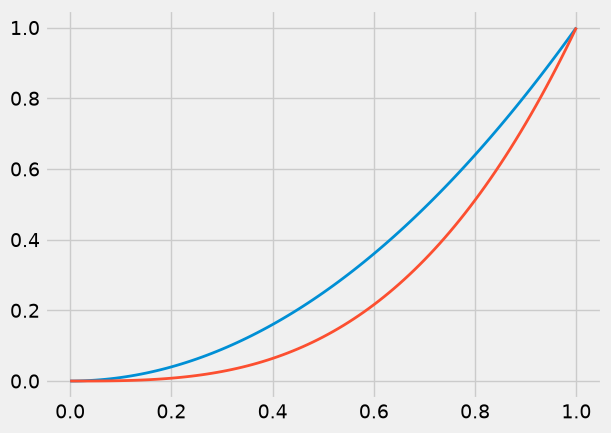

In [3]:
x = np.arange(0, 1.01, 0.01)
x_squared = x ** 2
x_cubed = x**3
plt.plot(x, x_squared, lw=2)
plt.plot(x, x_cubed, lw=2);


You can add titles, labels, and legends.

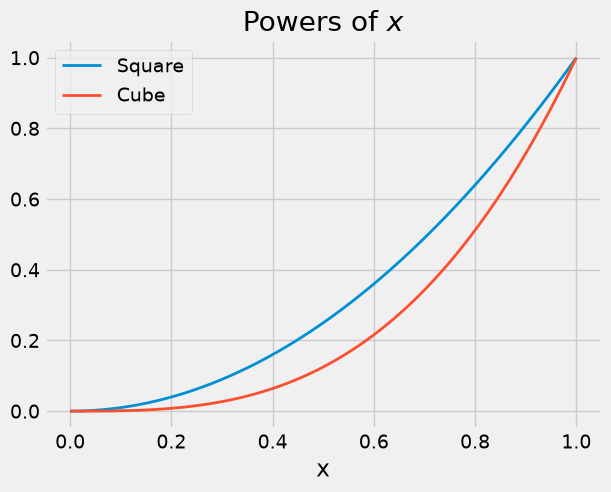

In [4]:
plt.plot(x, x_squared, lw=2, label = 'Square')
plt.plot(x, x_cubed, lw=2, label = 'Cube')
plt.legend()
plt.xlabel('x')
plt.title('Powers of $x$');


As another example, the code below was used in Homework 8 Exercise 4d to plot gamma densities.

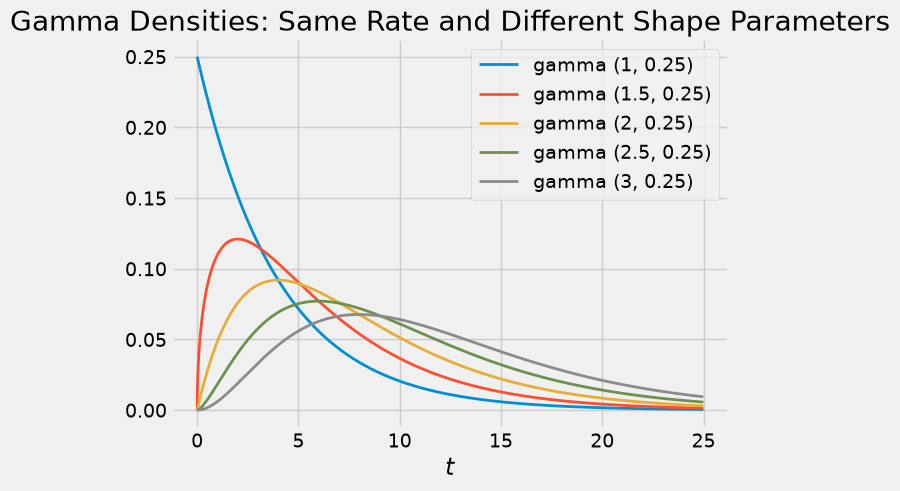

In [5]:
t = np.arange(0, 25, 0.01)
r_1 = stats.gamma.pdf(t, 1, scale=1/0.25)
r_1_5 = stats.gamma.pdf(t, 1.5, scale=1/0.25)
r_2 = stats.gamma.pdf(t, 2, scale=1/0.25)
r_2_5 = stats.gamma.pdf(t, 2.5, scale=1/0.25)
r_3 = stats.gamma.pdf(t, 3, scale=1/0.25)
plt.plot(t, r_1, lw=2, label='gamma (1, 0.25)')
plt.plot(t, r_1_5, lw=2, label='gamma (1.5, 0.25)')
plt.plot(t, r_2, lw=2, label='gamma (2, 0.25)')
plt.plot(t, r_2_5, lw=2, label='gamma (2.5, 0.25)')
plt.plot(t, r_3, lw=2, label='gamma (3, 0.25)')
plt.xlabel('$t$')
plt.legend()
plt.title('Gamma Densities: Same Rate and Different Shape Parameters');

\newpage

## 1. Poisson MGF ##
Let $X$ have Poisson($\mu$) distribution, and let $Y$ independent of $X$ have Poisson $(\lambda)$ distribution.

**a)** Derive the moment generating function of $X$. The answer is in the textbook. Your task here is to show why it's true.

**b)** Use the result of (a) to show that the distribution of $X+Y$ is Poisson.

\newpage

## 2. Gamma Tail Bound ##

Before you do this exercise, carefully study a [relevant example](https://data140.org/textbook/content/chapter-19/chernoff-bound/#application-to-the-normal-distribution) in the textbook. You will have to follow similar steps.

You will need the [mgf of the gamma distribution](https://data140.org/textbook/content/chapter-19/moment-generating-functions/#mgf-of-a-gamma-r-lambda-random-variable). Also remember that you found the gamma mean and variance in Homework 8.

If you want more information, read through [Ch. 12.3](https://data140.org/textbook/content/chapter-12/bounds/) (Tail Bounds), [Ch. 19.2](https://data140.org/textbook/content/chapter-19/moment-generating-functions/) (MGFs), and [Ch. 19.4](https://data140.org/textbook/content/chapter-19/chernoff-bound/) (Chernoff Bounds) in its entirety. If you have any questions, come to office hours or post them on Ed.

Let $X$ have the gamma $(r, \lambda)$ distribution. 

**a)** Show that $P(X \ge 2E(X)) \le \left(\frac{2}{e}\right)^r$.

**b)** Find Markov's and Chebyshev's bounds on $P(X \ge 2E(X))$. 

**c) [CODE]** Fix $\lambda = 1$. Display overlaid plots of the following four graphs as functions of $r$, for $r$ in the interval $(0.5, 15)$ :

- The exact tail probability $P(X \ge 2E(X))$
- The bound in Part **a**: $\left(\frac{2}{e}\right)^r$
- Chebyshev's bound on $P(X \ge 2E(X))$
- Markov's bound on $P(X \ge 2E(X))$

The code uses `plt.plot` which you have used before. The expression `stats.gamma.cdf(x, r, scale=1)` evaluates to the cdf of the gamma $(r, 1)$ distribution at the point $x$.

a)
$$
P(X \ge c) \le minM_X(t) e^{-tc} = min_{t>0} (\frac{\lambda}{\lambda - t})^r e^{-tc}
$$

$$
P(X \ge 2E(X)) \le min (\frac{\lambda}{\lambda - t})^r e^{-\frac{2tr}{\lambda}}
$$

$$
f(t) = (\frac{\lambda}{\lambda - t})^r e^{-\frac{2tr}{\lambda}}
$$
求导算出 $ t = \frac{\lambda}{2} $
带入即可证得

b)
Markov: 
$$
P(X \ge 2E(X)) \le \frac{E(X)}{2E(X)} = \frac{1}{2}
$$

che: 
$$
P(\mid X - E(X) \mid \ge E(X)) \le \frac{\sigma^2}{(E(X))^2} = \frac{1}{r}
$$
因为 X 是非负随机变量, 所以这就是答案. 另一边是概率为 0 的. 

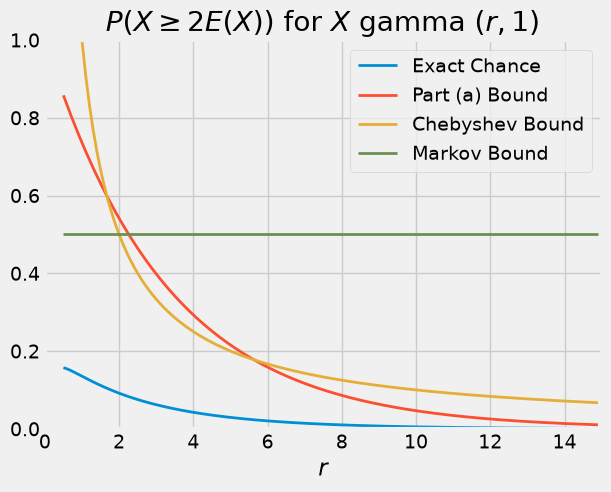

In [12]:
# Answer to c
r = np.arange(0.5, 15, 0.1) 

markov_bound = [1/2] * len(r)

chebyshev_bound = 1/r

part_a_bound = (2/np.e)**r

# Use as many lines as you need for the exact values
exact = 1 - stats.gamma.cdf(2 * r, r, scale=1)


plt.plot(r, exact, lw=2, label='Exact Chance')
plt.plot(r, part_a_bound, lw=2, label='Part (a) Bound')
plt.plot(r, chebyshev_bound, lw=2, label='Chebyshev Bound')
plt.plot(r, markov_bound, lw=2, label='Markov Bound')
plt.legend()
plt.xlabel('$r$')
plt.ylim(0, 1)
plt.xlim(0, 15)
plt.title('$P(X \geq 2E(X))$ for $X$ gamma $(r, 1)$');

\newpage

## 3. MLE of the Exponential Rate ##
For $n > 1$, let $X_1, X_2, \ldots , X_n$ be i.i.d. exponential $(\lambda )$ variables. 

**a)** Let $\hat{\lambda}_n$ be the maximum likelihood estimate (MLE) of the parameter $\lambda$. Find $\hat{\lambda}_n$ in terms of the sample mean $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$. The subscript $n$ in $\bar{X}_n$ is there to remind us that we have the average of $n$ values. It doesn't refer to the $n$th sampled value $X_n$.

**b)** Use facts about sums and linear transformations to find the distribution of $\bar{X}_n$ with little or no calculation. Recognize it as one of the famous ones and provide its name and parameters. Use it to find $E(\hat{\lambda}_n)$.

**c)** Is $\hat{\lambda}_n$ an unbiased estimate of $\lambda$? If it is biased, does it overestimate on average, or does it underestimate? Is it asymptotically unbiased? That is, does $E(\hat{\lambda}_n)$ converge to $\lambda$ as $n \to \infty$?

a)
$$
\hat{\lambda_n} = \frac{1}{\bar{X_n}}
$$

b)
Gamma(n, n\lambda)

$$
E(\bar{X_n}) = \frac{n}{n\lambda} = \frac{1}{\lambda}
$$

$$
E(\hat{\lambda_n}) = E(\frac{1}{\bar{X_n}}) = \frac{n\lambda}{n-1}
$$

c)
$$
E(\lambda) = \lambda
$$

所以这是一个有偏估计

高估

是的

\newpage

## 4. MLE and MAP Estimates ##

The coin is tossed 10 times and the resulting sequence is HTTHHHTHTH. In the parts below, we refer to this information as "the data".

**a)** Under the assumption that the coin lands heads with a fixed unknown probability $p$, find the MLE of $p$ based on the data. 

**b)** Suppose now that the coin lands heads with a random probability $X$. Let the prior density of $X$ be uniform on the unit interval. Find the MAP estimate of the probability of heads, given the data.

**c)** Show that if $r > 1$ and $s > 1$ then the mode of the beta $(r, s)$  distribution is $(r-1)/(r+s-2)$. Remember to ignore multiplicative constants and take the log before maximizing.

**d)** Suppose instead that the prior density of $X$ is $f(x) = 4x^3$ if $0 < x < 1$ and $0$ otherwise. Find the MAP estimate of the probability of heads, given the data.

a)
$$
Lik(p) = p^6(1-p)^4
$$

p = 3/5

b)
$ \frac{k}{n} $

c)
写出概率密度函数
取对数
求导
即可证得. 

d)
$$
\frac{3+k}{3+2k}
$$

\newpage

## 5. Heads in Tosses of a Random Coin
Before you do this exercise, carefully read through [Ch. 20.2](https://data140.org/textbook/content/chapter-20/independence-revisited/) (Independence, Revisisted) and [Ch. 21.1](https://data140.org/textbook/content/chapter-21/updating-and-prediction/) (Updating and Prediction). For more assistance, look through Ch. 21 Ex.2 and Ch. 21 Ex.3, which is done in Friday's section. If you have any questions, come to office hours or post them on Ed.

Let $X$ be a random proportion with a prior distribution that is beta $(2, 3)$. Given $X=p$, let $I_1, I_2, I_3, \ldots$ be i.i.d. Bernoulli $(p)$.

**a)** Plot the prior density of $X$.

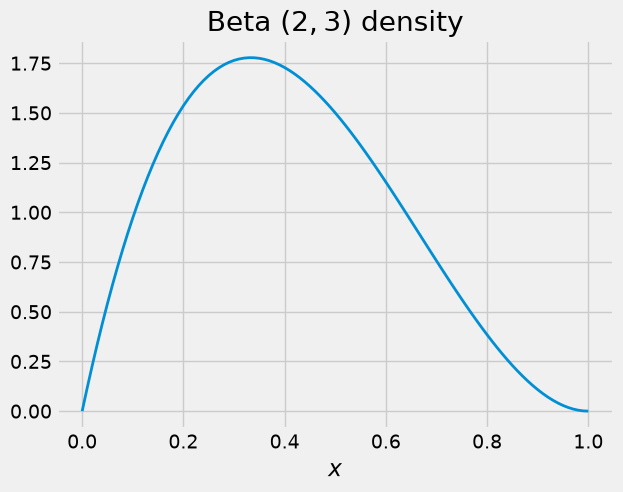

In [25]:
# Answer to a
x = np.arange(0, 1.01, 0.01)
y = stats.beta.pdf(x, a = 2, b = 3)

plt.plot(x, y, lw=2)
plt.xlabel('$x$')
plt.title('Beta $(2, 3)$ density');


**b)** Let $H_7 = \sum_{k=1}^7 I_k$. For each $h = 0, 1, \ldots, 7$, plot the posterior density of $X$ given $H_7 = h$. All $8$ plots should be on the same graph. 

Use as many lines of code as you need. You don't have to include labels and a legend, but the title should say which densities you are plotting.

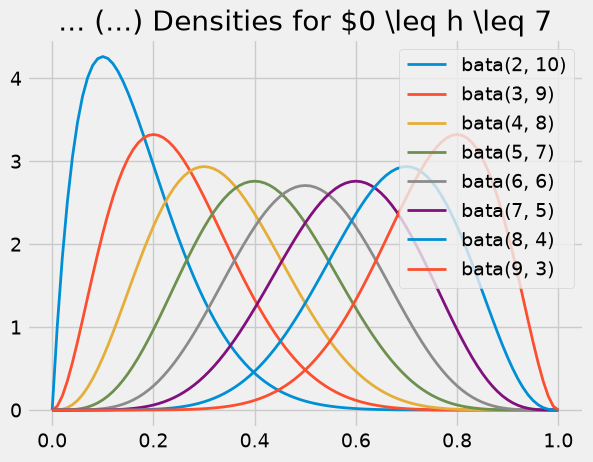

In [30]:
# Answer to b

h = np.arange(0, 8, 1)
x = np.arange(0, 1.01, 0.01)
for h in np.arange(0, 8, 1):
    y = stats.beta.pdf(x, a = 2+h, b = 3+(7-h))
    plt.plot(x, y, lw=2, label=f'bata({2+h}, {10-h})')

plt.legend()

plt.title('... (...) Densities for $0 \leq h \leq 7');


**c)** What is the MAP estimate of the random probability of heads given $H_7 = 2$? Calculate the estimate using the appropriate formula and confirm that your answer agrees with the estimate visible in the appropriate graph above.

**d)** Find $P(I_8 = 1 \mid H_7 = 2)$. Your answer should be a decimal value.

**e)** Find $P(I_8 = 1, I_9 = 1, I_{10} = 1 \mid H_7 = 2)$. Your answer should be a decimal value. Is it equal to the cube of the answer to Part (d)? If not, which is bigger?

c)
beta(4, 8)
map = 0.3

d)
P = \frac{r+k}{r+s+n} = \frac{1}{3} = 0.33

e)
$$P(I_8 = 1, I_9 = 1, I_{10} = 1 \mid H_7 = 2) = P(I_8 = 1 \mid H_7 = 2) \cdot P(I_9 = 1 \mid I_8 = 1, H_7 = 2) \cdot P(I_{10} = 1 \mid I_8 = 1, I_9 = 1, H_7 = 2) = 5/91$$

no 

5/91 is bigger. 

\newpage

## Submission Instructions ##

Many assignments throughout the course will have a written portion and a code portion. Please follow the directions below to properly submit both portions.

### Written Portion ###
*  Scan all the pages into a PDF. You can use any scanner or a phone using applications such as CamScanner. Please **DO NOT** simply take pictures using your phone. 
* Please start a new page for each question. If you have already written multiple questions on the same page, you can crop the image in CamScanner or fold your page over (the old-fashioned way). This helps expedite grading.
* It is your responsibility to check that all the work on all the scanned pages is legible.
* If you used $\LaTeX$ to do the written portions, you do not need to do any scanning; you can just download the whole notebook as a PDF via LaTeX.

### Code Portion ###
* Save your notebook using `File > Save and Checkpoint`.
* Generate a PDF file using `File > Download As > PDF via LaTeX`. This might take a few seconds and will automatically download a PDF version of this notebook.
    * If you have issues, please post a follow-up on the general Homework 10 Ed thread.
    
### Submitting ###
* Combine the PDFs from the written and code portions into one PDF. [Here](https://smallpdf.com/merge-pdf) is a useful tool for doing so. 
* Submit the assignment to Homework 10 on Gradescope. 
* **Make sure to assign each page of your pdf to the correct question.**
* **It is your responsibility to verify that all of your work shows up in your final PDF submission.**

If you are having difficulties scanning, uploading, or submitting your work, please read the [Ed Thread](https://edstem.org/us/courses/94054/discussion/7533569) on this topic and post a follow-up on the general Homework 10 Ed thread.